In [105]:
# 修改工作路径
import numpy as np
import pandas as pd

import os
os.chdir('/root/PQ20241025/') # 修改工作路径

In [106]:
data=pd.read_csv('./Major_revision/FieldData/wheat_yield.csv')
data

,OP,PRE,TMP,PET,SOC,pH,BULK,CEC,CLAY,SILT,...,Pfer,Nfer,Kfer,YIELD,X,Y,Region,YEAR,cooks_d,Region_old
0,38.3,614.3,13.2,1164.8,9.3,7.20,1.70,13.00,19.00,34.00,...,1.0,1,1,6547.5,119.796000,36.733440,山东省,2008,5.417987e-08,山东省
1,8.6,554.2,14.8,1149.9,4.1,8.50,1.70,13.00,19.00,34.00,...,0.0,1,1,7834.5,114.958190,37.070170,河北省,1900,1.420008e-05,河北省
2,13.9,528.0,14.3,1131.0,9.0,7.90,1.70,13.01,19.15,34.44,...,1.5,1,1,6579.0,35.614585,-0.184852,Africa,2012,1.151751e-08,河北省
3,30.5,642.9,13.7,1165.5,6.3,7.10,1.70,13.00,19.00,34.00,...,1.5,1,1,7032.0,117.212720,37.769140,山东省,2010,2.913458e-10,山东省
4,24.5,1011.0,16.6,1086.6,8.1,5.30,1.63,12.50,15.83,35.33,...,0.0,0,0,2775.0,117.467900,32.458110,安徽省,2010,6.867970e-06,安徽省
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56137,7.0,24.7,12.9,1105.8,6.7,7.64,1.78,18.69,24.58,36.53,...,1.5,1,1,7579.5,77.447230,37.975950,新疆维吾尔自治区,2010,1.527353e-05,新疆维吾尔自治区
56138,18.7,656.4,11.8,972.4,5.2,8.50,1.71,15.00,20.00,36.00,...,1.0,1,1,7000.0,109.312920,35.426140,陕西省,2009,1.804819e-05,陕西省
56139,22.5,678.9,13.1,1131.7,6.0,6.80,1.69,14.97,19.00,49.78,...,1.0,1,1,5410.0,120.478280,36.280220,山东省,2011,4.102421e-06,山东省
56140,10.2,859.2,15.0,796.7,18.6,7.80,1.72,11.44,19.78,31.66,...,0.0,0,0,2109.0,105.882500,32.609440,四川省,2010,3.570020e-06,四川省


# PINNs模型构建

In [107]:
# 基础包
import pandas as pd
import numpy as np
# 绘图的包
import matplotlib.pyplot as plt

import matplotlib as mpl
# PINNs的包
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# GIS的包
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import rasterio

import scipy.stats as stats

In [108]:
# 1. 检查CUDA可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [109]:
# 对训练集和测试集进行归一化
def custom_normalize(data, data_min, data_max):
    return (data - data_min) / (data_max - data_min + 1e-8)  # 加上一个小的数值防止除以零

def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [110]:
# 定义需要归一化的特征
features_to_normalize = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                         'CLAY', 'SILT', 'SAND', 'SLOPE', 'Pfer']

# 提取特征和目标变量
all_features = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                'CLAY', 'SILT', 'SAND', 'SLOPE', 'IRR', 'Pfer', 'Nfer', 'Kfer']
X = data[all_features].values  # 特征数据
Y = data['YIELD'].values.reshape(-1, 1)  # 目标数据

# 将数据转换为 PyTorch 张量
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

In [111]:
# 划分数据集，测试集占20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

In [112]:
# 获取需要归一化的列索引
normalize_indices = [all_features.index(f) for f in features_to_normalize]

# 计算训练集中需要归一化列的最小值和最大值
X_train_to_normalize = X_train[:, normalize_indices]
X_min = X_train_to_normalize.min(dim=0, keepdim=True)[0]
X_max = X_train_to_normalize.max(dim=0, keepdim=True)[0]

# 创建一个拷贝以存放归一化后的训练集和测试集
X_train_normalized = X_train.clone()
X_test_normalized = X_test.clone()

In [113]:
# 对需要归一化的列进行归一化
X_train_normalized[:, normalize_indices] = custom_normalize(X_train_to_normalize, X_min, X_max)
X_test_normalized[:, normalize_indices] = custom_normalize(X_test[:, normalize_indices], X_min, X_max)

X_param_normalized = X_train_normalized[:,1:16] #参数网络，排除OP
print('训练数据：',X_train_normalized.shape)
print('参数数据：',X_param_normalized.shape)

训练数据： torch.Size([44913, 16])
参数数据： torch.Size([44913, 15])


In [114]:
# 对目标变量归一化
Y_min = Y_train.min()
Y_max = Y_train.max()
Y_train_normalized = custom_normalize(Y_train, Y_min, Y_max)
Y_test_normalized = custom_normalize(Y_test, Y_min, Y_max)

In [115]:
# 转换为需要梯度的张量并移动到设备上
X_param = X_param_normalized.to(device)

data_x_train = X_train_normalized.requires_grad_(True).to(device)
data_y_train = Y_train_normalized.to(device)

data_x_test = X_test_normalized.to(device)
data_y_test = Y_test_normalized.to(device)

# 检查 requires_grad 属性
print("data_x_train requires_grad:", data_x_train.requires_grad)  # 应为 True
print("data_y_train requires_grad:", data_y_train.requires_grad)  # 应为 False
print("data_x_test requires_grad:", data_x_test.requires_grad)    # 应为 False

# 检查张量设备
print("data_x_train device:", data_x_train.device)  # 应与 device 一致
print("data_y_train device:", data_y_train.device)  # 应与 device 一致
print("data_x_test device:", data_x_test.device)    # 应与 device 一致

data_x_train requires_grad: True
data_y_train requires_grad: False
data_x_test requires_grad: False
data_x_train device: cuda:0
data_y_train device: cuda:0
data_x_test device: cuda:0


In [116]:
# ===== 构造 OP collocation points（步长=5）=====
op_grid = torch.arange(0, 101, 5, device=device).float()   # 0,5,...,100  共21个点
op_grid_norm = custom_normalize(op_grid, X_min[:, 0].to(device), X_max[:, 0].to(device))

n_train = data_x_train.shape[0]
n_op = op_grid_norm.shape[0]

# 把每个训练样本复制 n_op 份，并把第0列(OP)替换为 op_grid_norm
x_colloc = data_x_train.detach().clone()   # 先不带图
x_colloc = x_colloc.repeat_interleave(n_op, dim=0)  # [n_train*n_op, 16]
x_colloc[:, 0] = op_grid_norm.repeat(n_train)       # 每个样本对应一条OP曲线

x_colloc = x_colloc.requires_grad_(True)            # 关键：要对OP求导
x_param_colloc = x_colloc[:, 1:16]                  # param net输入(不含OP)

In [117]:
import random
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 尽量使用确定性算法（⚠️ 有些算子会报错）
    torch.use_deterministic_algorithms(False)

set_seed(7)

In [118]:
# 主网络：用于预测
class YieldPredictionModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(YieldPredictionModel, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# 子网络：动态生成 a, b, c 参数
class ParameterNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=3):
        super(ParameterNetwork, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
        

    def forward(self, x):
        return self.network(x)

In [119]:
# 实例化模型并移动到设备上
# YieldPredictionModel 输入特征包括 OP 和其他特征，共15个特征
yield_model = YieldPredictionModel(input_size=16, hidden_sizes=[32, 64, 32], output_size=1).to(device)

# ParameterNetwork 输入特征不包括 OP 和 'IRR', 'Pfer', 'Nfer', 'Kfer'，共10个特征
# PRE, TMP, PET, SOC, pH, BULK, CLAY, SILT, SAND, SLOPE
param_model = ParameterNetwork(input_size=15, hidden_sizes=[50]).to(device)

# 定义优化器，将主网络和参数网络的参数一起优化
optimizer = torch.optim.Adam(
    [
        {"params": yield_model.parameters(), "lr": 0.01},
        {"params": param_model.parameters(), "lr": 0.0001},  # 甚至 1e-5
    ]
)

In [120]:
def pinn_loss_with_boundary(
    y_pred_obs, y_true_obs,
    data_x_obs,              # 原训练观测点（用于数据loss）
    x_colloc, x_param_colloc,# 新增：OP梯度配点（用于物理loss）
    epoch, epochs
):
    # ========= 数据误差（观测点）=========
    mse_loss_data = nn.MSELoss()(y_pred_obs, y_true_obs)

    # ========= 物理误差（collocation点：沿OP=0..100）=========
    y_pred_col = yield_model(x_colloc)
    abc_col = param_model(x_param_colloc)

    a = abc_col[:, 0]
    b = abc_col[:, 1]
    c = abc_col[:, 2]

    dy_dop = torch.autograd.grad(
        y_pred_col, x_colloc,
        grad_outputs=torch.ones_like(y_pred_col),
        create_graph=True
    )[0][:, 0]  # 对第0列OP求导

    # 你的目标微分形式（按你原来的写法）
    phys_target = 10 * b * (c * torch.exp(-c * 10 * x_colloc[:, 0]))
    diff_loss = torch.mean((dy_dop - phys_target) ** 2)

    # ========= 正则（collocation点上也可以约束）=========
    l2_reg_c = torch.norm(torch.relu(c - 2), 2) + torch.norm(torch.relu(1 - c), 2)
    l2_reg_b = torch.norm(torch.relu(b - 2), 2) + torch.norm(torch.relu(0 - b), 2)
    l2_reg_a = torch.norm(torch.relu(a - 1), 2) + torch.norm(torch.relu(0 - a), 2)
    reg_loss = l2_reg_a + l2_reg_b + l2_reg_c

    # ========= 权重（你原来的）=========
    lambda_data = 100
    lambda_diff = 10 * min(epoch / (0.5 * epochs), 500.0)
    lambda_reg = 0.3

    total = lambda_data*mse_loss_data + lambda_diff*diff_loss + lambda_reg*reg_loss

    return total, lambda_data*mse_loss_data, lambda_diff*diff_loss, lambda_reg*reg_loss, a.mean(), b.mean(), c.mean()

In [121]:
# 切换到训练模式
yield_model.train()
param_model.train()
print("Model is now in training mode.")

Model is now in training mode.


In [122]:
loss_history = []
epochs = 16500

for epoch in range(epochs):
    optimizer.zero_grad()

    # 观测点预测（数据loss）
    y_pred_train_obs = yield_model(data_x_train)

    # collocation点在每个epoch构造也行；如果你放在epoch外面，这里就不用重复建
    # 建议：如果显存顶不住，就每次随机抽一部分训练样本做collocation
    # 这里先用“全量训练样本 × 21个OP点”的版本

    loss, data_loss, diff_loss, reg_loss, a, b, c = pinn_loss_with_boundary(
        y_pred_train_obs, data_y_train,
        data_x_train,
        x_colloc, x_param_colloc,
        epoch, epochs
    )

    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Total={loss.item():.4f} Data={data_loss.item():.4f} Diff={diff_loss.item():.4f} Reg={reg_loss.item():.4f}")

Epoch [500/16500] Total=2.7114 Data=1.2209 Diff=0.0397 Reg=1.4507
Epoch [1000/16500] Total=1.3632 Data=1.1628 Diff=0.0176 Reg=0.1827
Epoch [1500/16500] Total=1.2013 Data=1.1336 Diff=0.0163 Reg=0.0514
Epoch [2000/16500] Total=1.1111 Data=1.0939 Diff=0.0173 Reg=0.0000
Epoch [2500/16500] Total=1.1018 Data=1.0878 Diff=0.0140 Reg=0.0000
Epoch [3000/16500] Total=1.0399 Data=1.0240 Diff=0.0159 Reg=0.0000
Epoch [3500/16500] Total=1.0741 Data=1.0608 Diff=0.0133 Reg=0.0000
Epoch [4000/16500] Total=0.9729 Data=0.9611 Diff=0.0118 Reg=0.0000
Epoch [4500/16500] Total=0.9507 Data=0.9378 Diff=0.0128 Reg=0.0000
Epoch [5000/16500] Total=0.9081 Data=0.8981 Diff=0.0099 Reg=0.0000
Epoch [5500/16500] Total=0.8807 Data=0.8715 Diff=0.0092 Reg=0.0000
Epoch [6000/16500] Total=0.8615 Data=0.8524 Diff=0.0091 Reg=0.0000
Epoch [6500/16500] Total=0.8252 Data=0.8163 Diff=0.0089 Reg=0.0000
Epoch [7000/16500] Total=0.8190 Data=0.8100 Diff=0.0089 Reg=0.0000
Epoch [7500/16500] Total=0.7882 Data=0.7791 Diff=0.0090 Reg=0.0

效果评估

In [124]:
# 开始模型评估模式
yield_model.eval()
param_model.eval()
print("Model is now in evaluation mode.")

Model is now in evaluation mode.


In [128]:
# 在测试集洱和训练集上进行预测
with torch.no_grad():
    y_pred_test = yield_model(data_x_test)

with torch.no_grad():
    y_pred_train = yield_model(data_x_train)

In [129]:
# 将预测值和真实值反归一化
y_pred_test_denormalized = custom_denormalize(y_pred_test, Y_min, Y_max)
y_test_denormalized = custom_denormalize(data_y_test, Y_min, Y_max)

y_pred_train_denormalized = custom_denormalize(y_pred_train, Y_min, Y_max)
y_train_denormalized = custom_denormalize(data_y_train, Y_min, Y_max)

# 将数据从 PyTorch 张量转换为 NumPy 数组
y_pred_test_np = y_pred_test_denormalized.cpu().numpy()
y_test_np = y_test_denormalized.cpu().numpy()

# 将数据从 PyTorch 张量转换为 NumPy 数组
y_pred_train_np = y_pred_train_denormalized.cpu().numpy()
y_train_np = y_train_denormalized.cpu().numpy()

# 计算 R2
r2_test = r2_score(y_test_np, y_pred_test_np)
r2_train = r2_score(y_train_np, y_pred_train_np)
print(f'R2 on test set: {r2_test:.4f}')
print(f'R2 on train set: {r2_train:.4f}')

R2 on test set: 0.7354
R2 on train set: 0.7979


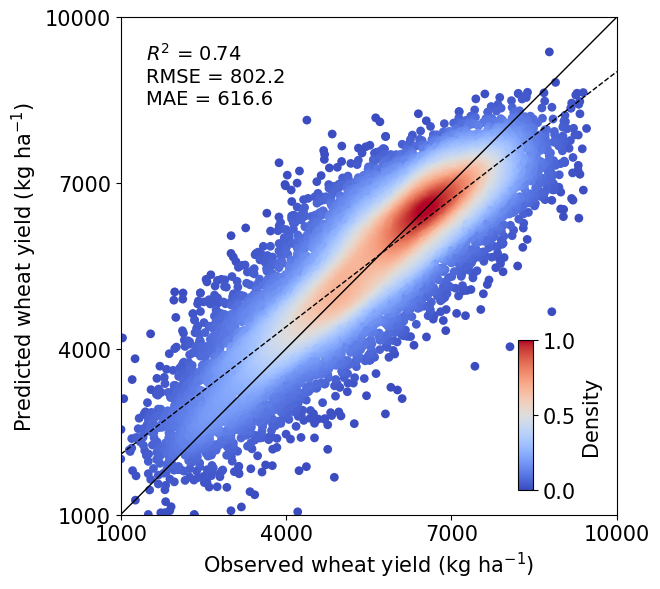

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x_obs = np.asarray(y_test_np).ravel()
y_pre = np.asarray(y_pred_test_np).ravel()

mask = np.isfinite(x_obs) & np.isfinite(y_pre)
x_obs = x_obs[mask]
y_pre = y_pre[mask]

# ===== KDE 密度 =====
xy = np.vstack([x_obs, y_pre])
z = gaussian_kde(xy)(xy)

# ===== 归一化到 0–1 =====
z = (z - z.min()) / (z.max() - z.min())

# 高密度点后画
idx = z.argsort()
x_obs, y_pre, z = x_obs[idx], y_pre[idx], z[idx]

plt.figure(figsize=(6.7, 6))

sc = plt.scatter(x_obs, y_pre, c=z, s=40, cmap='coolwarm', vmin=0, vmax=1, edgecolors='none')

# ===== colorbar =====
ax = plt.gca()
cax = ax.inset_axes([0.8, 0.05, 0.03, 0.3])  # [左, 下, 宽, 高]
cbar = plt.colorbar(sc, cax=cax,fraction=0.1, pad=0.05, aspect=20)
cbar.set_label('Density', fontsize=15)
cbar.set_ticks([0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=15)

# ===== 1:1 线 =====
plt.plot([1000, 10000], [1000, 10000], color='black', linewidth=1)

# ===== 拟合线 =====
coef = np.polyfit(x_obs, y_pre, 1)
fit_line = np.poly1d(coef)
x_fit = np.linspace(1000, 10000, 200)
plt.plot(x_fit, fit_line(x_fit), linestyle='--', color='black', linewidth=1)

# ===== 指标文本（左上角）=====
R2 = r2_score(x_obs, y_pre)
RMSE = np.sqrt(mean_squared_error(x_obs, y_pre))
MAE = mean_absolute_error(x_obs, y_pre)

plt.text(0.05, 0.95, f'$R^2$ = {R2:.2f}\nRMSE = {RMSE:.1f}\nMAE = {MAE:.1f}',
    transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

# ===== 坐标轴 =====
plt.xlim(1000, 10000)
plt.ylim(1000, 10000)
plt.xticks(np.arange(1000, 10001, 3000), fontsize=15)
plt.yticks(np.arange(1000, 10001, 3000), fontsize=15)
plt.xlabel('Observed wheat yield (kg ha$^{-1}$)', fontsize=15)
plt.ylabel('Predicted wheat yield (kg ha$^{-1}$)', fontsize=15)

plt.tight_layout()
plt.show()